In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

DISK_CSV = Path('/home/igor/igor_repos/scaling_laws/Scaling-up-measurement-noise-scaling-laws/analysis/2026-04-08_veryfing_data_correctness/collect_mi_results_from_disk.csv')
ORIG_CSV = Path('/home/igor/igor_repos/scaling_laws/Scaling-up-measurement-noise-scaling-laws/collect_mi_results.csv')

df_disk = pd.read_csv(DISK_CSV)
df_orig = pd.read_csv(ORIG_CSV)
print(f'Disk CSV: {len(df_disk)} rows')
print(f'Orig CSV: {len(df_orig)} rows')

In [33]:
def plot_mi_scaling_side_by_side(df_orig, df_disk):
    """Plot MI vs number of cells: rows=dataset×signal, cols=algorithm pairs."""
    # Build row index: (dataset, signal) pairs
    all_ds_sig = sorted(
        set(zip(df_orig['dataset'], df_orig['signal'])) | set(zip(df_disk['dataset'], df_disk['signal']))
    )
    algorithms = sorted(set(df_orig['algorithm'].unique()) | set(df_disk['algorithm'].unique()))
    n_rows = len(all_ds_sig)
    n_col_pairs = len(algorithms)

    source_labels = ['Paper results (NVIDIA)', 'Regenerated (AMD)']
    source_edge_colors = ['#2166ac', '#b2182b']

    from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

    fig = plt.figure(figsize=(3.4 * n_col_pairs * 2, 3.5 * n_rows + 1.2))

    outer_gs = GridSpec(n_rows, n_col_pairs, figure=fig,
                        top=0.90, bottom=0.06, left=0.08, right=0.88,
                        hspace=0.35, wspace=0.4)

    axes = np.empty((n_rows, n_col_pairs * 2), dtype=object)
    for i in range(n_rows):
        for j in range(n_col_pairs):
            inner_gs = GridSpecFromSubplotSpec(1, 2, subplot_spec=outer_gs[i, j], wspace=0.08)
            axes[i, j * 2] = fig.add_subplot(inner_gs[0, 0])
            axes[i, j * 2 + 1] = fig.add_subplot(inner_gs[0, 1])

    for i in range(n_rows):
        for jj in range(1, n_col_pairs * 2):
            axes[i, jj].sharey(axes[i, 0])

    all_qualities = sorted(set(df_orig['quality'].unique()) | set(df_disk['quality'].unique()))
    norm = mcolors.LogNorm(vmin=min(all_qualities), vmax=max(all_qualities))
    cmap = plt.cm.viridis

    sources = [(source_labels[0], df_orig), (source_labels[1], df_disk)]

    for i, (ds, sig) in enumerate(all_ds_sig):
        for j, algo in enumerate(algorithms):
            for s, (src_name, df_src) in enumerate(sources):
                ax = axes[i, j * 2 + s]
                sub = df_src[(df_src['dataset'] == ds) & (df_src['algorithm'] == algo) & (df_src['signal'] == sig)]

                for spine in ax.spines.values():
                    spine.set_edgecolor(source_edge_colors[s])
                    spine.set_linewidth(2)

                if sub.empty:
                    ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                            transform=ax.transAxes, color='gray', fontsize=10)
                    ax.set_xscale('log')
                else:
                    qualities = sorted(sub['quality'].unique())
                    for q in qualities:
                        color = cmap(norm(q))
                        q_df = sub[sub['quality'] == q]
                        agg = q_df.groupby('size')['mi_value'].agg(['mean', 'std', 'count']).reset_index()
                        agg = agg.sort_values('size')
                        agg['sem'] = (agg['std'] / np.sqrt(agg['count'])).fillna(0)

                        ax.errorbar(agg['size'], agg['mean'], yerr=agg['sem'],
                                    marker='o', markersize=2.5, linewidth=0.9, capsize=1.5,
                                    color=color, alpha=0.85)

                    ax.set_xscale('log')

                if i == n_rows - 1:
                    ax.set_xlabel('Number of cells', fontsize=9)
                if j == 0 and s == 0:
                    ax.set_ylabel(f'MI value ({sig})', fontsize=9)

                if i == 0:
                    ax.set_title(src_name, fontsize=7,
                                 color=source_edge_colors[s], fontweight='bold')

                # Dataset label on far left
                if j == 0 and s == 0:
                    ax.annotate(ds, xy=(0, 0.5), xytext=(-0.55, 0.5),
                                xycoords='axes fraction', textcoords='axes fraction',
                                fontsize=12, fontweight='bold', ha='center', va='center',
                                rotation=90)

                ax.tick_params(labelsize=7)
                if not (j == 0 and s == 0):
                    ax.tick_params(labelleft=False)

    # Algorithm group labels above the grid
    for j, algo in enumerate(algorithms):
        left_pos = axes[0, j * 2].get_position()
        right_pos = axes[0, j * 2 + 1].get_position()
        cx = (left_pos.x0 + right_pos.x1) / 2
        cy = left_pos.y1 + 0.035
        fig.text(cx, cy, algo, ha='center', va='bottom',
                 fontsize=12, fontweight='bold')

    # Source legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='white', edgecolor=source_edge_colors[0], linewidth=2.5,
                             label=source_labels[0]),
                       Patch(facecolor='white', edgecolor=source_edge_colors[1], linewidth=2.5,
                             label=source_labels[1])]
    fig.legend(handles=legend_elements, loc='upper right', fontsize=10,
               frameon=True, bbox_to_anchor=(0.99, 0.99))

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.5])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('Quality (downsampling ratio)', fontsize=10)
    cbar.ax.tick_params(labelsize=8)

    fig.suptitle('MI vs Number of cells — Paper results (NVIDIA) vs Regenerated (AMD)',
                 fontsize=14, fontweight='bold', y=0.99)
    plt.show()
    return fig

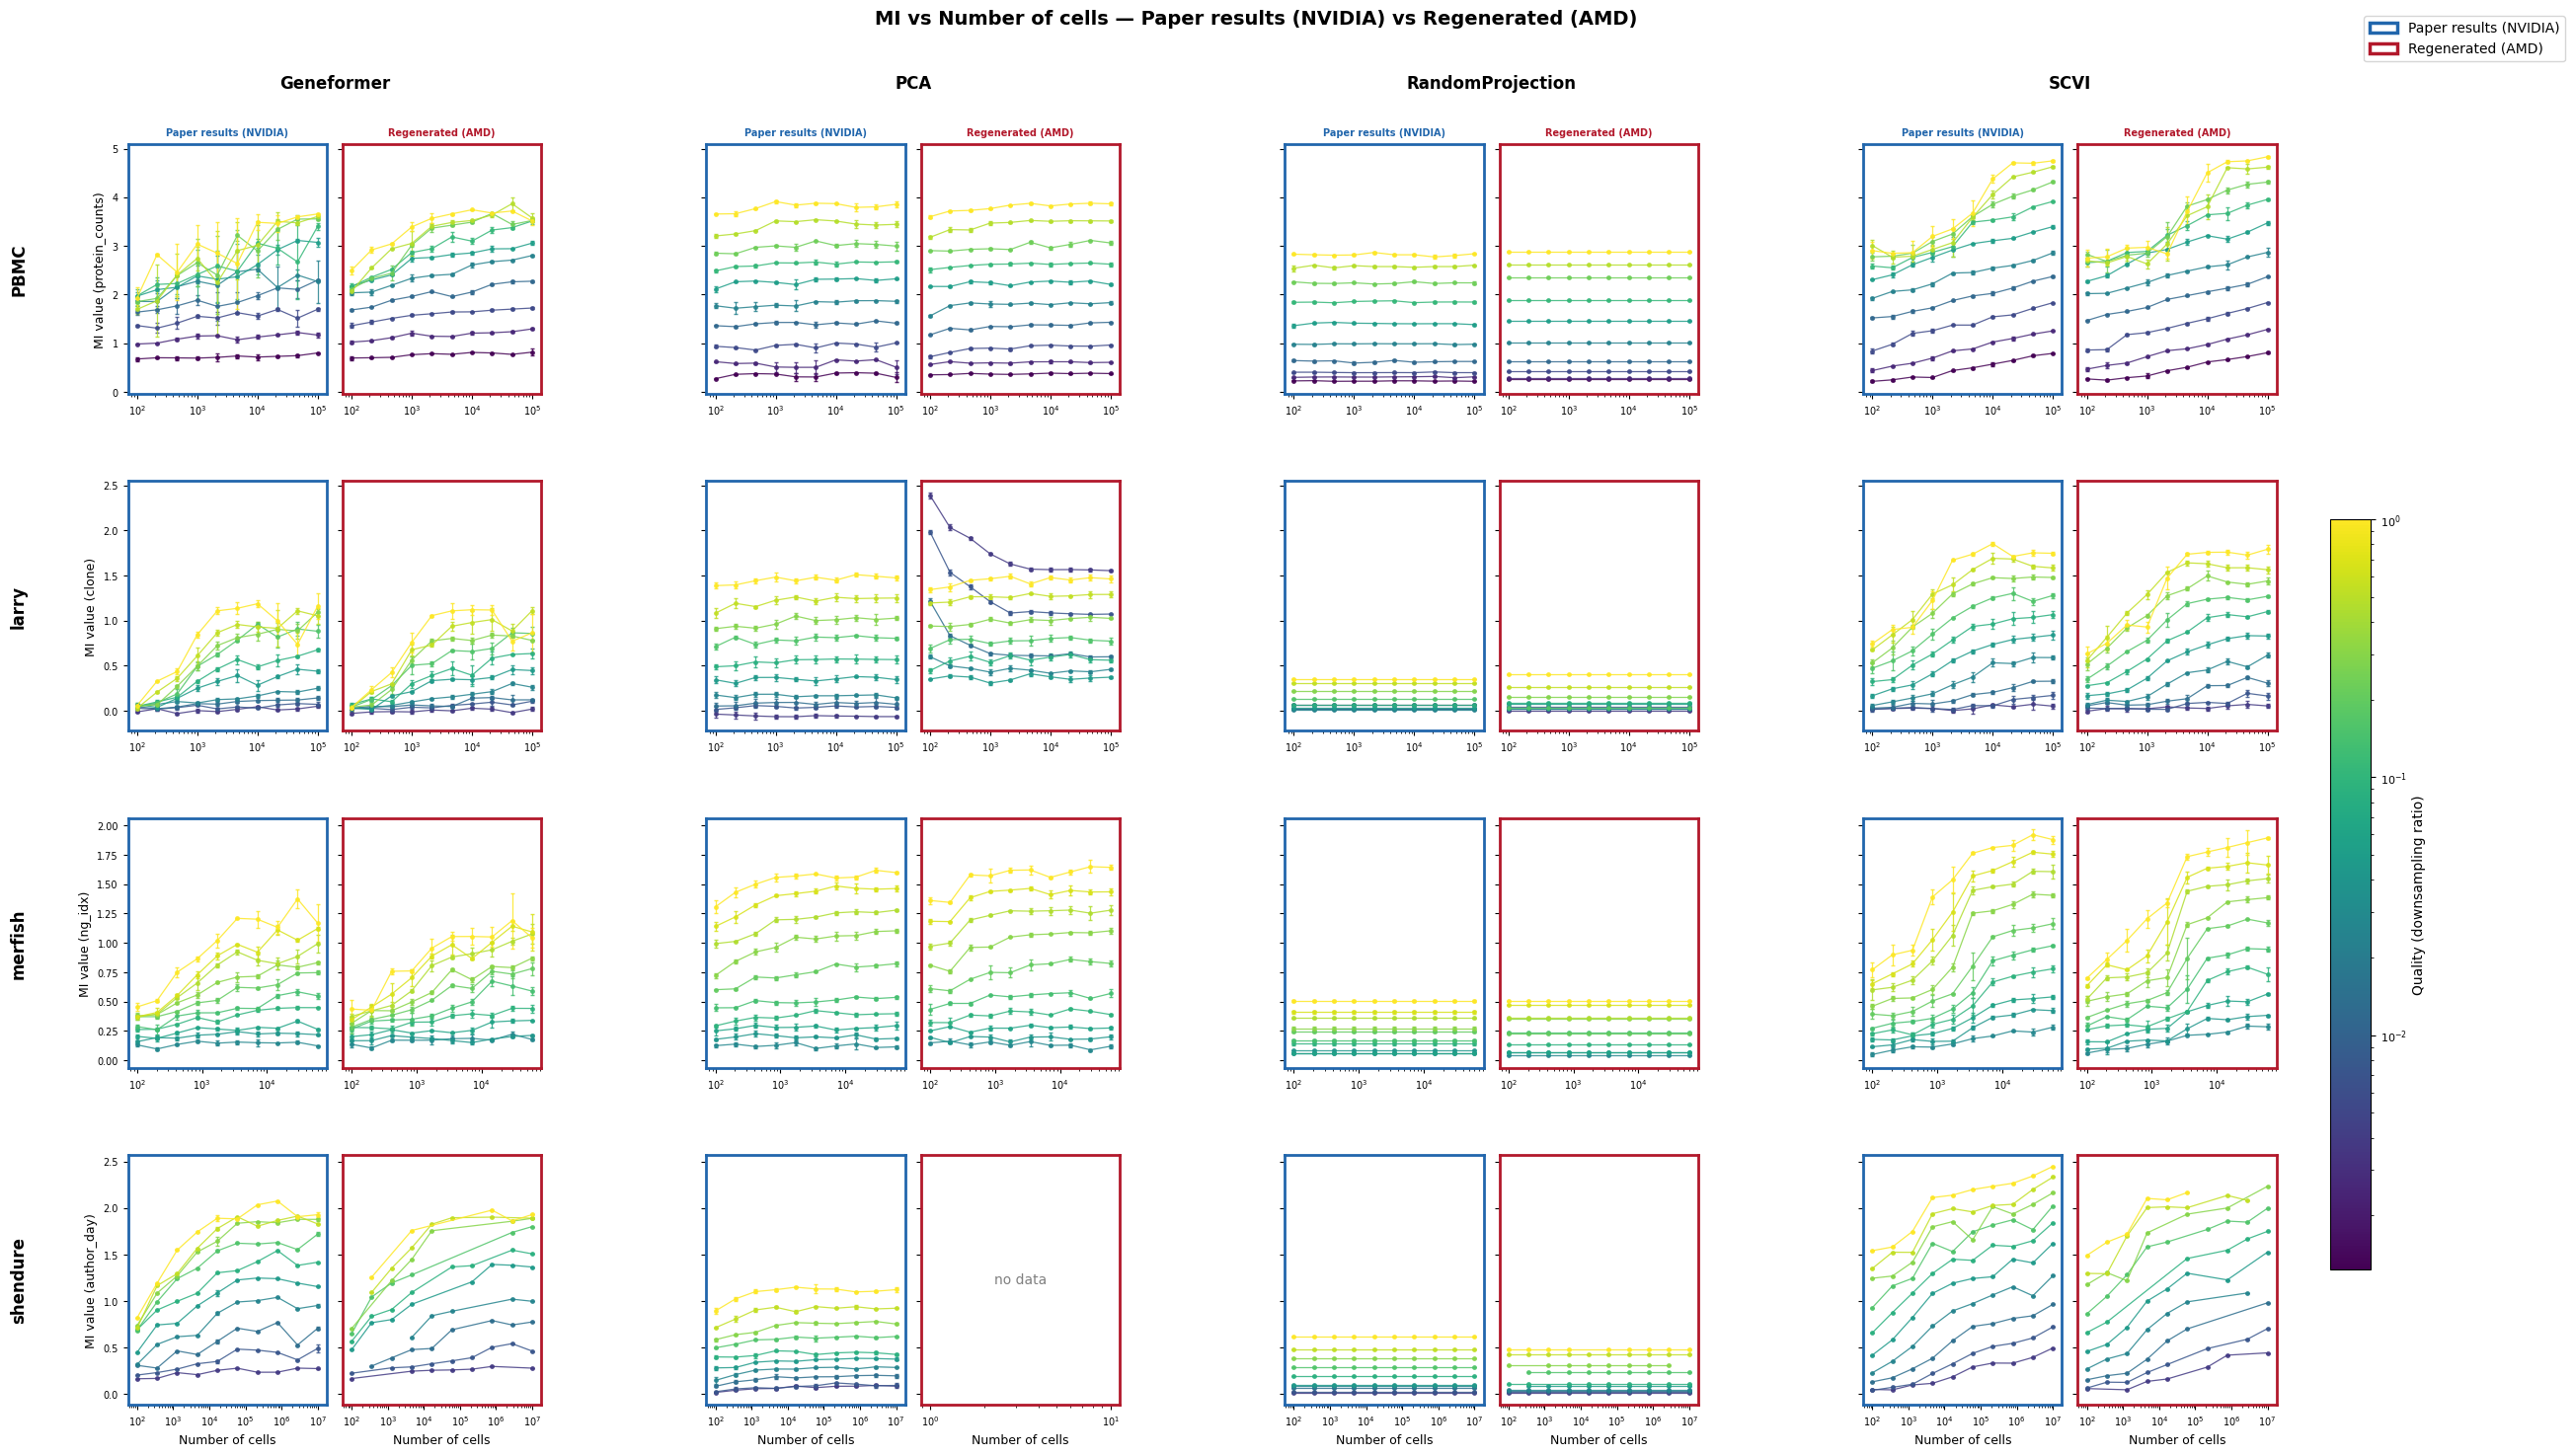

In [34]:
fig = plot_mi_scaling_side_by_side(df_orig[df_orig['signal'] != 'celltype.l3'],
                                  df_disk[df_disk['signal'] != 'celltype.l3'])

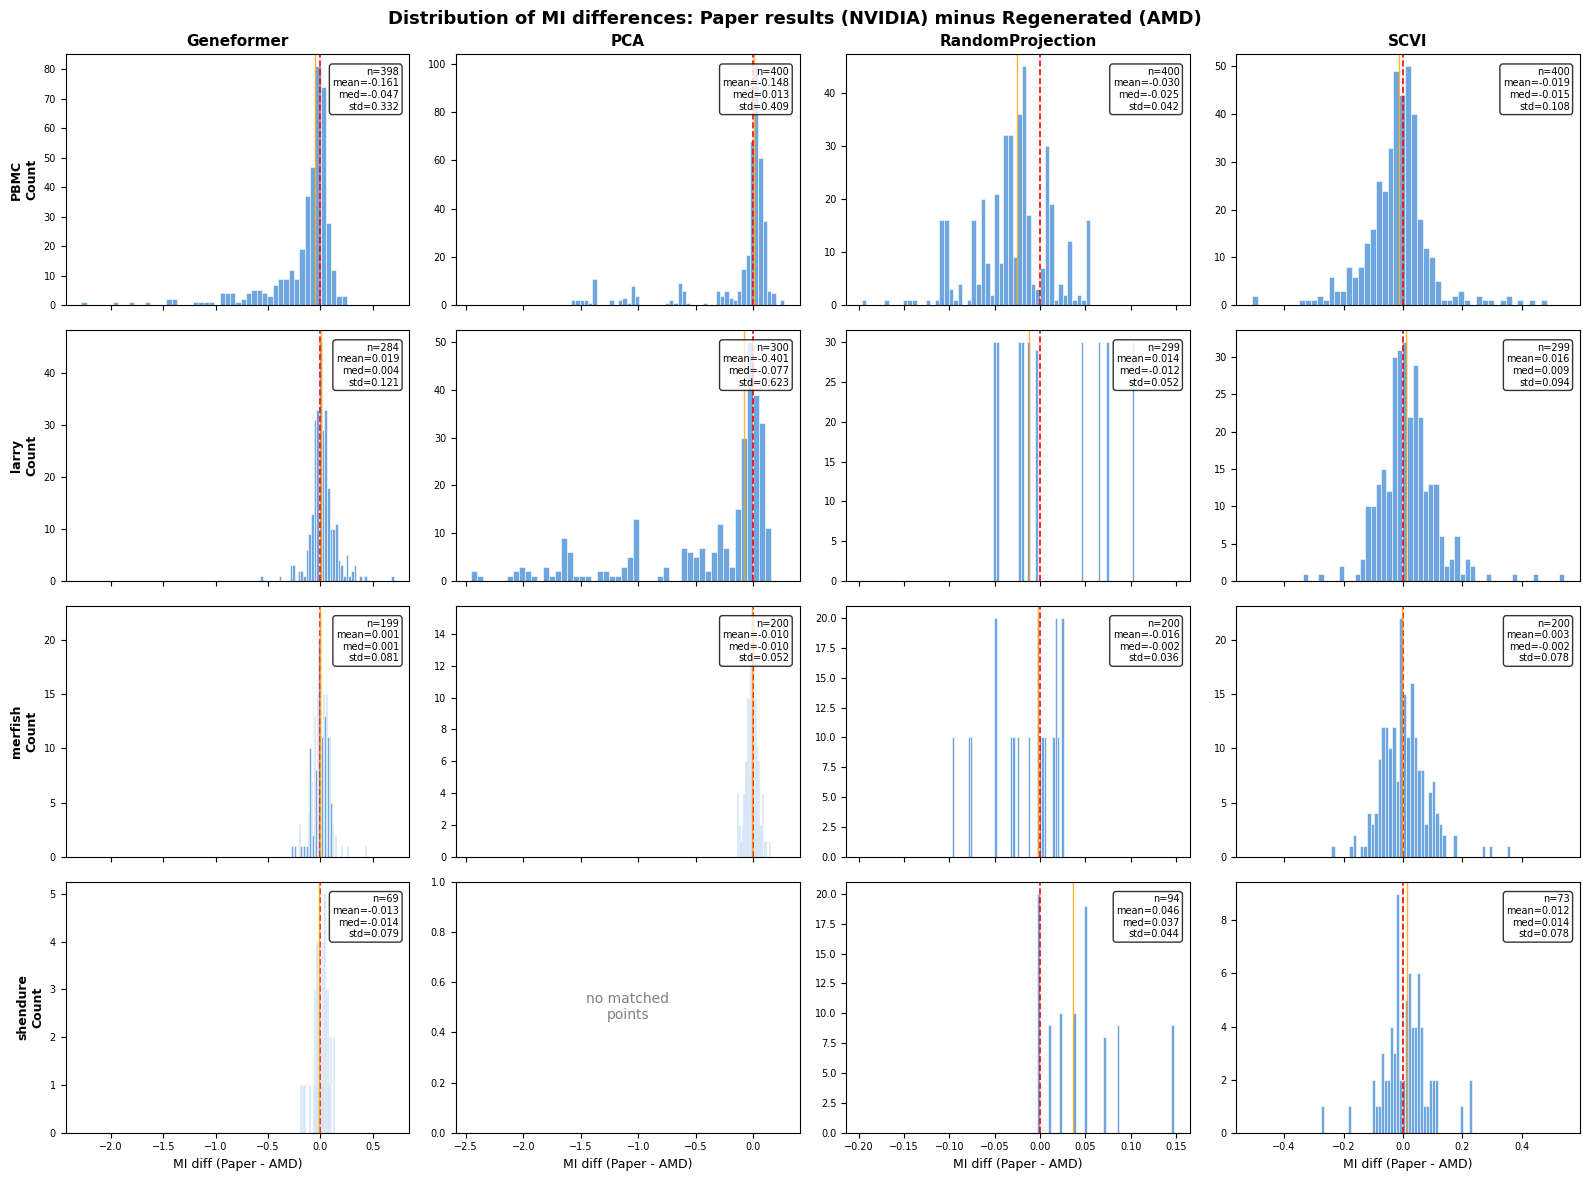

In [36]:
# Point-matched difference distribution: Paper (NVIDIA) vs Regenerated (AMD)
join_cols = ['dataset', 'size', 'quality', 'algorithm', 'signal', 'seed']
matched = df_orig.merge(df_disk, on=join_cols, suffixes=('_paper', '_amd'))
matched['mi_diff'] = matched['mi_value_paper'] - matched['mi_value_amd']

datasets = sorted(matched['dataset'].unique())
algorithms = sorted(matched['algorithm'].unique())

fig, axes = plt.subplots(len(datasets), len(algorithms),
                         figsize=(4 * len(algorithms), 3 * len(datasets)),
                         squeeze=False, sharex='col')

for i, ds in enumerate(datasets):
    for j, algo in enumerate(algorithms):
        ax = axes[i, j]
        sub = matched[(matched['dataset'] == ds) & (matched['algorithm'] == algo)]

        if sub.empty:
            ax.text(0.5, 0.5, 'no matched\npoints', ha='center', va='center',
                    transform=ax.transAxes, color='gray')
        else:
            ax.hist(sub['mi_diff'], bins=50, color='#4a90d9', edgecolor='white',
                    linewidth=0.5, alpha=0.8)
            ax.axvline(0, color='red', ls='--', lw=1.2)
            # Stats annotation
            med = sub['mi_diff'].median()
            mean = sub['mi_diff'].mean()
            std = sub['mi_diff'].std()
            ax.axvline(med, color='orange', ls='-', lw=1, alpha=0.8)
            ax.text(0.97, 0.95,
                    f'n={len(sub)}\nmean={mean:.3f}\nmed={med:.3f}\nstd={std:.3f}',
                    transform=ax.transAxes, fontsize=7, va='top', ha='right',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

        if i == 0:
            ax.set_title(algo, fontsize=11, fontweight='bold')
        if i == len(datasets) - 1:
            ax.set_xlabel('MI diff (Paper - AMD)', fontsize=9)
        if j == 0:
            ax.set_ylabel(f'{ds}\nCount', fontsize=9, fontweight='bold')
        ax.tick_params(labelsize=7)

fig.suptitle('Distribution of MI differences: Paper results (NVIDIA) minus Regenerated (AMD)',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()